In [108]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [109]:
ad_df = pd.read_csv("/Users/abhijeetsinghparihar/Desktop/Projects/Supply Chain Project/Conversion-Lens/data/ab_data.csv")
ad_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294480 entries, 0 to 294479
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294480 non-null  int64 
 1   timestamp     294480 non-null  object
 2   group         294480 non-null  object
 3   landing_page  294480 non-null  object
 4   converted     294480 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB


In [110]:
ad_df.head()

,user_id,timestamp,group,landing_page,converted
0,851104,11:48.6,control,old_page,0
1,804228,01:45.2,control,old_page,0
2,661590,55:06.2,treatment,new_page,0
3,853541,28:03.1,treatment,new_page,0
4,864975,52:26.2,control,old_page,1


### Info
- No Null values
- datatype problme with timedelta 

NOTE:- timestamp is the time spend by user on the ecommerce website [for both converted and non converted scenerio]

In [111]:
## data type conversion 
print(ad_df["timestamp"].sample(10)) # format = mm:ss.s
print(ad_df["timestamp"].shape[0])

285050    01:12.8
90390     24:38.6
279728    33:15.7
176892    14:18.4
5825      08:02.8
97366     14:03.5
93573     31:23.9
272369    28:50.4
67735     28:47.5
176393    05:12.7
Name: timestamp, dtype: object
294480


In [112]:
td = pd.to_timedelta('00:' + ad_df['timestamp'])
seconds = td.dt.total_seconds()
minutes = seconds / 60

print(minutes.describe())

count    294480.000000
mean         30.052248
std          17.303301
min           0.000000
25%          15.081667
50%          30.056667
75%          45.026667
max          59.998333
Name: timestamp, dtype: float64


In [113]:
ad_df["timestamp_min"] = minutes

In [114]:
ad_df.head()

,user_id,timestamp,group,landing_page,converted,timestamp_min
0,851104,11:48.6,control,old_page,0,11.810000
1,804228,01:45.2,control,old_page,0,1.753333
2,661590,55:06.2,treatment,new_page,0,55.103333
3,853541,28:03.1,treatment,new_page,0,28.051667
4,864975,52:26.2,control,old_page,1,52.436667


### Data Exploration

In [115]:
# Unique users
d1 = ad_df["user_id"].value_counts().reset_index(name="count").sort_values(by="count", ascending = False)
is1 = d1.iloc[0:4]
print(ad_df[ad_df["user_id"].isin(is1.user_id)].sort_values(by="user_id"))

        user_id timestamp      group landing_page  converted  timestamp_min
47219    654395   12:25.4  treatment     new_page          1      12.423333
179175   654395   57:21.0    control     new_page          0      57.350000
56183    703112   07:53.4    control     new_page          1       7.890000
113672   703112   19:42.1  treatment     new_page          0      19.701667
110111   712134   37:21.2  treatment     old_page          0      37.353333
129192   712134   51:38.8    control     old_page          0      51.646667
221114   856917   17:16.2    control     new_page          0      17.270000
240173   856917   01:20.8  treatment     new_page          0       1.346667


In [116]:
print(d1[d1["count"] == 2].shape[0])

3895


### data integrity issue

Treatment group should be shown new landing page and Control group should be shown old_page, this might be tracking script error, or session cookies exprires. Dropping those user entirely from the dataset.

In [117]:
ad_df = ad_df[((ad_df['group'] == 'treatment') & (ad_df['landing_page'] == 'new_page')) |
              ((ad_df['group'] == 'control') & (ad_df['landing_page'] == 'old_page'))]

# Check the new shape (should be 290,585 rows)
print(ad_df.shape[0])

290587


In [118]:
d1 = ad_df["user_id"].value_counts().reset_index(name="count").sort_values(by="count", ascending = False)
print(d1.head())

        user_id  count
0        759899      2
1        773192      2
290583   889019      1
193720   803683      1
193726   679687      1


In [119]:
ad_df[ad_df["user_id"] == 759899]
# this is correct as it is two instances by the user 759899 from the treatment group.

,user_id,timestamp,group,landing_page,converted,timestamp_min
250001,759899,07:36.1,treatment,new_page,0,7.601667
294478,759899,20:29.0,treatment,new_page,0,20.483333


In [120]:
print(ad_df.converted.value_counts())
print(f"Total conversion rate is {ad_df.converted.mean() * 100.0}")

converted
0    255834
1     34753
Name: count, dtype: int64
Total conversion rate is 11.959585253297636


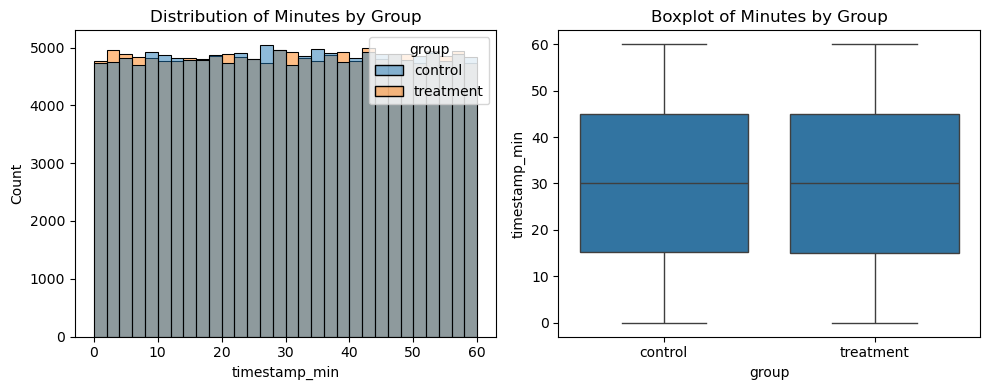

In [124]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(data=ad_df, x="timestamp_min", hue="group", bins=30)
plt.title("Distribution of Minutes by Group")
plt.subplot(1, 2, 2)

sns.boxplot(data=ad_df, x="group", y="timestamp_min")
plt.title("Boxplot of Minutes by Group")
plt.tight_layout()
plt.show()

In [125]:
ad_df.columns

Index(['user_id', 'timestamp', 'group', 'landing_page', 'converted',
       'timestamp_min'],
      dtype='object')

In [126]:
ad_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 290587 entries, 0 to 294479
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   user_id        290587 non-null  int64  
 1   timestamp      290587 non-null  object 
 2   group          290587 non-null  object 
 3   landing_page   290587 non-null  object 
 4   converted      290587 non-null  int64  
 5   timestamp_min  290587 non-null  float64
dtypes: float64(1), int64(2), object(3)
memory usage: 15.5+ MB


In [127]:
# relevant columns
columns_to_keep = ['user_id', 'group', 'converted', 'timestamp_min']
df_clean = ad_df[columns_to_keep]

# Split the data into two distinct DataFrames
control_group = df_clean[df_clean['group'] == 'control']
treatment_group = df_clean[df_clean['group'] == 'treatment']

# Verify the split
print(f"Control size: {control_group.shape[0]}")
print(f"Treatment size: {treatment_group.shape[0]}")

Control size: 145274
Treatment size: 145313
